Tahap Klasifikasi Dari Clustering Data makanan dan minuman (misalnya: data jenis makanan, penjualan F&B)
Sumber dataset: https://www.kaggle.com/datasets/sebastianwillmann/beverage-sales

# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
# Import pustaka dasar untuk manipulasi data
import pandas as pd
import numpy as np

# Import pustaka untuk visualisasi data
import seaborn as sns
import matplotlib.pyplot as plt

# Import pustaka untuk pemrosesan data dan model machine learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Import pustaka untuk evaluasi model
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [2]:
# Baca file CSV
data = pd.read_csv('beverage_sales_clustering.csv')

# Tampilkan DataFrame untuk memastikan telah dibaca dengan benar
data.info()
print('\n')
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77402 entries, 0 to 77401
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       77402 non-null  object 
 1   Customer_ID    77402 non-null  object 
 2   Customer_Type  77402 non-null  object 
 3   Product        77402 non-null  int64  
 4   Category       77402 non-null  int64  
 5   Unit_Price     77402 non-null  float64
 6   Quantity       77402 non-null  float64
 7   Discount       77402 non-null  float64
 8   Total_Price    77402 non-null  float64
 9   Region         77402 non-null  int64  
 10  Order_Date     77402 non-null  object 
 11  Cluster        77402 non-null  int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 7.1+ MB




,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
0,ORD30565,CUS8839,B2C,10,2,-0.259275,-0.636314,-0.664441,-0.232718,2,2021-02-05,0
1,ORD1713842,CUS4827,B2C,13,1,-0.272228,-0.375608,-0.664441,-0.210239,3,2022-03-25,0
2,ORD2367638,CUS3732,B2C,32,3,-0.363580,-0.822533,-0.664441,-0.255236,8,2021-10-21,0
3,ORD2952688,CUS1519,B2C,33,2,-0.356762,-0.785289,-0.664441,-0.253941,8,2023-02-27,0
4,ORD535815,CUS1605,B2C,11,3,-0.326085,-0.450095,-0.664441,-0.234346,12,2021-07-14,0


# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

1. Pembersihan Data

In [3]:
# Hapus kolom yang kurang relevan
data = data.drop(columns=['Order_ID','Customer_ID','Order_Date'])

# Hapus data duplikat
data = data.drop_duplicates(ignore_index=True)

# Cek data
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42762 entries, 0 to 42761
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer_Type  42762 non-null  object 
 1   Product        42762 non-null  int64  
 2   Category       42762 non-null  int64  
 3   Unit_Price     42762 non-null  float64
 4   Quantity       42762 non-null  float64
 5   Discount       42762 non-null  float64
 6   Total_Price    42762 non-null  float64
 7   Region         42762 non-null  int64  
 8   Cluster        42762 non-null  int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 2.9+ MB


2. Pemisahan Fitur (X) dan Target (y)

In [4]:
# Pisahkan fitur (X) dan target (y)
X = data.drop(columns=['Cluster'])
y = data['Cluster']

X.head()


,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region
0,B2C,10,2,-0.259275,-0.636314,-0.664441,-0.232718,2
1,B2C,13,1,-0.272228,-0.375608,-0.664441,-0.210239,3
2,B2C,32,3,-0.363580,-0.822533,-0.664441,-0.255236,8
3,B2C,33,2,-0.356762,-0.785289,-0.664441,-0.253941,8
4,B2C,11,3,-0.326085,-0.450095,-0.664441,-0.234346,12


3. Normalisasi Data

In [5]:
# Buat instance MinMaxScaler
scaler = MinMaxScaler()

# Normalisasi semua kolom numerik
numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns
X[numeric_columns] = scaler.fit_transform(X[numeric_columns])

X.head()


,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region
0,B2C,0.256410,0.666667,0.272876,0.076923,0.0,0.073122,0.133333
1,B2C,0.333333,0.333333,0.241830,0.184615,0.0,0.145174,0.200000
2,B2C,0.820513,1.000000,0.022876,0.000000,0.0,0.000943,0.533333
3,B2C,0.846154,0.666667,0.039216,0.015385,0.0,0.005093,0.533333
4,B2C,0.282051,1.000000,0.112745,0.153846,0.0,0.067903,0.800000


4. Encoding Data Kategorikal

In [6]:
# Buat instance LabelEncoder
encoder = LabelEncoder()

# Melakukan encoding pada kolom kategorikal
categorical_columns = X.select_dtypes(include=['object']).columns
for column in categorical_columns:
    X[column] = encoder.fit_transform(X[column])

X.head()


,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region
0,1,0.256410,0.666667,0.272876,0.076923,0.0,0.073122,0.133333
1,1,0.333333,0.333333,0.241830,0.184615,0.0,0.145174,0.200000
2,1,0.820513,1.000000,0.022876,0.000000,0.0,0.000943,0.533333
3,1,0.846154,0.666667,0.039216,0.015385,0.0,0.005093,0.533333
4,1,0.282051,1.000000,0.112745,0.153846,0.0,0.067903,0.800000


5. Data Splitting

In [7]:
# Split data menjadi set pelatihan dan set uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

# Tampilkan bentuk set pelatihan dan set uji untuk memastikan split
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")


Training set shape: X_train=(34209, 8), y_train=(34209,)
Test set shape: X_test=(8553, 8), y_test=(8553,)


# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [8]:
# 4. Membangun Model Klasifikasi
## a. Membangun Model Klasifikasi
# Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

# Misalkan X dan y sudah didefinisikan sebagai fitur dan label
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

# Melatih model Naive Bayes dan Random Forest
nb = GaussianNB().fit(X_train, y_train)
rf = RandomForestClassifier(random_state=69).fit(X_train, y_train)

print("Training Model selesai.")

Training Model selesai.


# Tulis narasi atau penjelasan algoritma yang digunakan.

# - Naive Bayes: Menggunakan teorema Bayes untuk klasifikasi berbasis probabilitas.
# - Random Forest: Menggunakan banyak decision tree untuk meningkatkan akurasi dan mengurangi overfitting.


## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

## a. Evaluasi Model Random Forest

Random Forest Classification Report:
               precision    recall  f1-score   support

           0    1.00000   1.00000   1.00000      4763
           1    0.97780   0.97780   0.97780      1036
           2    0.98541   0.98369   0.98455      1717
           3    0.98077   0.98361   0.98219      1037

    accuracy                        0.99205      8553
   macro avg    0.98600   0.98627   0.98613      8553
weighted avg    0.99205   0.99205   0.99205      8553



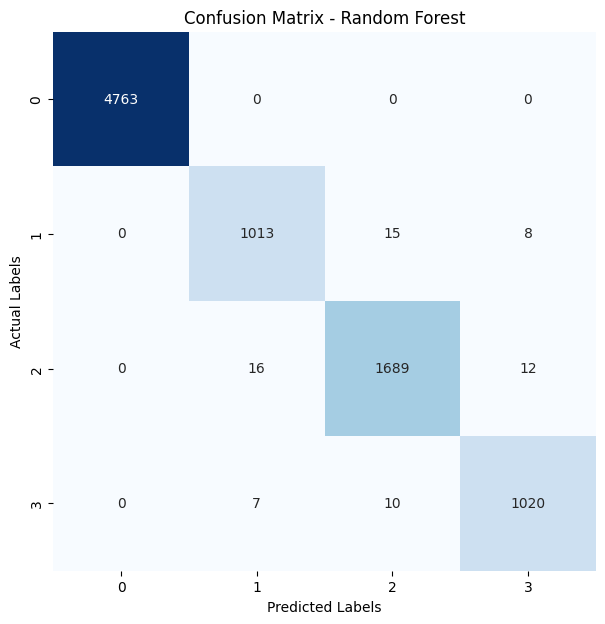

In [9]:
# Melakukan prediksi dan menghitung metrik evaluasi
unique_labels = sorted(set(y))
rf_y_pred = rf.predict(X_test)

print("Random Forest Classification Report:\n", classification_report(y_test, rf_y_pred, digits=5))

# Confusion Matrix untuk Random Forest
rf_cm = confusion_matrix(y_test, rf_y_pred)
plt.figure(figsize=(7, 7))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=unique_labels,
            yticklabels=unique_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix - Random Forest')
plt.show()

## b. Evaluasi Model Naive Bayes

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0    1.00000   1.00000   1.00000      4763
           1    0.83784   0.98745   0.90651      1036
           2    0.99327   0.85906   0.92130      1717
           3    0.94926   0.99229   0.97030      1037

    accuracy                        0.96925      8553
   macro avg    0.94509   0.95970   0.94953      8553
weighted avg    0.97285   0.96925   0.96928      8553



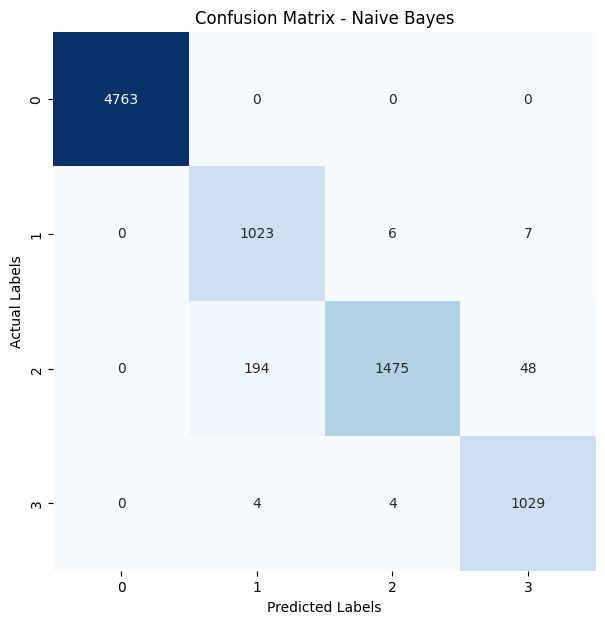

In [10]:
# Melakukan prediksi dan menghitung metrik evaluasi
nb_y_pred = nb.predict(X_test)

print("Naive Bayes Classification Report:\n", classification_report(y_test, nb_y_pred, digits=5))

# Confusion Matrix untuk Naive Bayes
nb_cm = confusion_matrix(y_test, nb_y_pred)
plt.figure(figsize=(7, 7))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=unique_labels,
            yticklabels=unique_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

## c. Perbandingan Hasil Evaluasi

In [11]:
# Hitung laporan klasifikasi untuk kedua model
rf_report = classification_report(y_test, rf_y_pred, digits=5, output_dict=True)
nb_report = classification_report(y_test, nb_y_pred, digits=5, output_dict=True)

# Ekstrak metrik yang relevan (akurasi, presisi, recall, dan F1-score)
metrics = {
    'Model': ['Random Forest', 'Naive Bayes'],
    'Accuracy': [rf_report['accuracy'], nb_report['accuracy']],
    'Precision': [rf_report['weighted avg']['precision'], nb_report['weighted avg']['precision']],
    'Recall': [rf_report['weighted avg']['recall'], nb_report['weighted avg']['recall']],
    'F1-Score': [rf_report['weighted avg']['f1-score'], nb_report['weighted avg']['f1-score']]
}

# Membuat DataFrame untuk perbandingan hasil
comparison_df = pd.DataFrame(metrics)
print(comparison_df)


           Model  Accuracy  Precision    Recall  F1-Score
0  Random Forest  0.992050   0.992051  0.992050  0.992050
1    Naive Bayes  0.969251   0.972854  0.969251  0.969276


## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

# Hyperparameter tuning untuk Random Forest

In [12]:
rf_param_dist = {
    'n_estimators': np.arange(50, 500, 50),
    'max_depth': np.arange(5, 50, 5),
    'min_samples_split': np.arange(2, 20, 2),
    'min_samples_leaf': np.arange(1, 20, 2),
    'max_features': [None, 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=69),
    param_distributions=rf_param_dist,
    n_iter=70,
    cv=5,
    verbose=2,
    random_state=69,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)
print("Best parameters for Random Forest:", rf_random_search.best_params_)


Fitting 5 folds for each of 70 candidates, totalling 350 fits
Best parameters for Random Forest: {'n_estimators': 450, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': None, 'max_depth': 25, 'bootstrap': True}


# Hyperparameter tuning untuk Naive Bayes

In [13]:
nb_param_dist = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

nb_random_search = RandomizedSearchCV(
    estimator=GaussianNB(),
    param_distributions=nb_param_dist,
    n_iter=70,
    cv=5,
    verbose=2,
    random_state=69,
    n_jobs=-1
)

nb_random_search.fit(X_train, y_train)
print("Best parameters for Naive Bayes:", nb_random_search.best_params_)

Fitting 5 folds for each of 70 candidates, totalling 350 fits
Best parameters for Naive Bayes: {'var_smoothing': 0.03511191734215131}


## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.

## 1. Gunakan model dengan hyperparameter terbaik


# Random Forest - Gunakan model dengan hyperparameter terbaik

In [14]:
print("Best Random Forest Hyperparameters:", rf_random_search.best_params_)
print("Best Random Forest Accuracy:", rf_random_search.best_score_)

rf_best_model = rf_random_search.best_estimator_
rf_best_model_y_pred = rf_best_model.predict(X_test)


Best Random Forest Hyperparameters: {'n_estimators': 450, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': None, 'max_depth': 25, 'bootstrap': True}
Best Random Forest Accuracy: 0.9954105704377729


# Naive Bayes - Gunakan model dengan hyperparameter terbaik

In [15]:
print("Best Naive Bayes Hyperparameters:", nb_random_search.best_params_)
print("Best Naive Bayes Accuracy:", nb_random_search.best_score_)

nb_best_model = nb_random_search.best_estimator_
nb_best_model_y_pred = nb_best_model.predict(X_test)

Best Naive Bayes Hyperparameters: {'var_smoothing': 0.03511191734215131}
Best Naive Bayes Accuracy: 0.9791575982304195


## 2. Hitung ulang metrik evaluasi untuk melihat peningkatan performa

In [16]:
# Evaluasi model Random Forest setelah tuning
print("Random Forest (Best Model) Classification Report:\n", classification_report(y_test, rf_best_model_y_pred, digits=5))

# Evaluasi model Naive Bayes setelah tuning
print("Naive Bayes (Best Model) Classification Report:\n", classification_report(y_test, nb_best_model_y_pred, digits=5))

# Bandingkan hasil evaluasi kedua model setelah tuning
rf_best_report = classification_report(y_test, rf_best_model_y_pred, digits=5, output_dict=True)
nb_best_report = classification_report(y_test, nb_best_model_y_pred, digits=5, output_dict=True)

# Ekstrak metrik yang relevan (Accuracy, Precision, Recall, F1-Score)
metrics_tuned = {
    'Model': ['Random Forest (Tuned)', 'Naive Bayes (Tuned)'],
    'Accuracy': [rf_best_report['accuracy'], nb_best_report['accuracy']],
    'Precision': [rf_best_report['weighted avg']['precision'], nb_best_report['weighted avg']['precision']],
    'Recall': [rf_best_report['weighted avg']['recall'], nb_best_report['weighted avg']['recall']],
    'F1-Score': [rf_best_report['weighted avg']['f1-score'], nb_best_report['weighted avg']['f1-score']]
}

# Membuat DataFrame untuk perbandingan performa setelah tuning
df_tuned = pd.DataFrame(metrics_tuned)
print(df_tuned)

Random Forest (Best Model) Classification Report:
               precision    recall  f1-score   support

           0    1.00000   1.00000   1.00000      4763
           1    0.98551   0.98456   0.98503      1036
           2    0.99183   0.99010   0.99096      1717
           3    0.98847   0.99229   0.99038      1037

    accuracy                        0.99521      8553
   macro avg    0.99145   0.99174   0.99159      8553
weighted avg    0.99521   0.99521   0.99521      8553

Naive Bayes (Best Model) Classification Report:
               precision    recall  f1-score   support

           0    1.00000   1.00000   1.00000      4763
           1    0.90328   0.95560   0.92871      1036
           2    0.97171   0.92021   0.94526      1717
           3    0.96067   0.98939   0.97482      1037

    accuracy                        0.97732      8553
   macro avg    0.95892   0.96630   0.96220      8553
weighted avg    0.97784   0.97732   0.97732      8553

                   Model  Accu

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Bandingkan hasil evaluasi sebelum dan setelah tuning (jika dilakukan).
2. Identifikasi kelemahan model, seperti:
  - Precision atau Recall rendah untuk kelas tertentu.
  - Apakah model mengalami overfitting atau underfitting?
3. Berikan rekomendasi tindakan lanjutan, seperti mengumpulkan data tambahan atau mencoba algoritma lain jika hasil belum memuaskan.

## 1. Bandingkan hasil evaluasi sebelum dan setelah tuning

In [17]:
# Menggabungkan dua DataFrame hasil evaluasi sebelum dan setelah tuning
df_merged = pd.concat([comparison_df, df_tuned], ignore_index=True)

# Menukar posisi baris ke-1 dan ke-2 agar hasil sebelum dan sesudah tuning mudah dibandingkan
df_merged.loc[[1, 2]] = df_merged.loc[[2, 1]].values

# Menampilkan hasil perbandingan
print("Perbandingan Hasil Evaluasi Sebelum dan Sesudah Tuning:")
print(df_merged)


Perbandingan Hasil Evaluasi Sebelum dan Sesudah Tuning:
                   Model  Accuracy  Precision    Recall  F1-Score
0          Random Forest  0.992050   0.992051  0.992050  0.992050
1  Random Forest (Tuned)  0.995206   0.995207  0.995206  0.995206
2            Naive Bayes  0.969251   0.972854  0.969251  0.969276
3    Naive Bayes (Tuned)  0.977318   0.977838  0.977318  0.977322


## 2. Identifikasi kelemahan model

In [18]:
# Analisis berdasarkan Precision dan Recall untuk melihat apakah ada kelas yang memiliki performa rendah
print("\nAnalisis Precision dan Recall untuk setiap model:")

# Menampilkan laporan klasifikasi untuk model sebelum dan setelah tuning
print("\nRandom Forest Sebelum Tuning:\n", classification_report(y_test, rf_y_pred, digits=5))
print("\nRandom Forest Setelah Tuning:\n", classification_report(y_test, rf_best_model_y_pred, digits=5))
print("\nNaive Bayes Sebelum Tuning:\n", classification_report(y_test, nb_y_pred, digits=5))
print("\nNaive Bayes Setelah Tuning:\n", classification_report(y_test, nb_best_model_y_pred, digits=5))

# Mengecek apakah model mengalami overfitting atau underfitting dengan membandingkan akurasi training dan testing
rf_train_acc = rf_best_model.score(X_train, y_train)
rf_test_acc = rf_best_model.score(X_test, y_test)

nb_train_acc = nb_best_model.score(X_train, y_train)
nb_test_acc = nb_best_model.score(X_test, y_test)

print(f"\nRandom Forest - Akurasi Training: {rf_train_acc:.5f}, Akurasi Testing: {rf_test_acc:.5f}")
print(f"Naive Bayes - Akurasi Training: {nb_train_acc:.5f}, Akurasi Testing: {nb_test_acc:.5f}")



Analisis Precision dan Recall untuk setiap model:

Random Forest Sebelum Tuning:
               precision    recall  f1-score   support

           0    1.00000   1.00000   1.00000      4763
           1    0.97780   0.97780   0.97780      1036
           2    0.98541   0.98369   0.98455      1717
           3    0.98077   0.98361   0.98219      1037

    accuracy                        0.99205      8553
   macro avg    0.98600   0.98627   0.98613      8553
weighted avg    0.99205   0.99205   0.99205      8553


Random Forest Setelah Tuning:
               precision    recall  f1-score   support

           0    1.00000   1.00000   1.00000      4763
           1    0.98551   0.98456   0.98503      1036
           2    0.99183   0.99010   0.99096      1717
           3    0.98847   0.99229   0.99038      1037

    accuracy                        0.99521      8553
   macro avg    0.99145   0.99174   0.99159      8553
weighted avg    0.99521   0.99521   0.99521      8553


Naive Bayes Se

## 3. Rekomendasi Tindakan Lanjutan

Rekomendasi Tindakan Lanjutan:

Eksplorasi Model Lain

Mencoba algoritma lain seperti XGBoost atau LightGBM untuk membandingkan performa dengan Random Forest dan Naive Bayes.

Peningkatan Fitur

Menggunakan teknik feature engineering untuk menambah informasi penting, misalnya fitur gabungan atau transformasi logaritmik untuk menangani skala data.

Validasi Model Lebih Lanjut

Menerapkan cross-validation untuk memastikan model tidak overfitting.

Menguji model dengan data baru atau unseen data untuk melihat bagaimana model bekerja di dunia nyata.

Optimasi Hyperparameter Lebih Lanjut

Coba strategi tuning lanjutan seperti Bayesian Optimization atau Grid Search untuk meningkatkan performa model lebih jauh.